# Codificación de circuitos para la corrección cuántica de errores
- Actividad de la asignatura: Información Cuántica.
- Profesor: Jenaro Gallego Gómez
- Autor: Enrique Prada Vázquez
- Fecha: 18/06/2026

## Introducción
En computación cuántica, el ruido ambiental puede provocar tres tipos principales de fallos: errores de volteo de bit ($X$), errores de volteo de fase ($Z$) y errores de volteo de bit y fase ($Y$). Dado que el Teorema de No Clonación impide duplicar la información para protegerla, Peter Shor propuso en 1995 una solución que codifica un único cúbit original en un bloque redundante de 9 cúbits físicos. Este sistema se basa en una codificación en cascada: un código externo que entrelaza tres bloques independientes para detectar y corregir errores de fase, y tres códigos internos que operan dentro de cada bloque para corregir errores de bit mediante una regla de mayoría de votos.

Este cuaderno propone una implementación y pruebas de este algoritmo en Qiskit, diseñadas para simular y validar de manera práctica su robustez frente a diferentes escenarios de error.

A continuación, se muestran los diagramas del circuito completo que se implementará en las siguientes celdas, detallando la distribución de compuertas y registros involucrados:

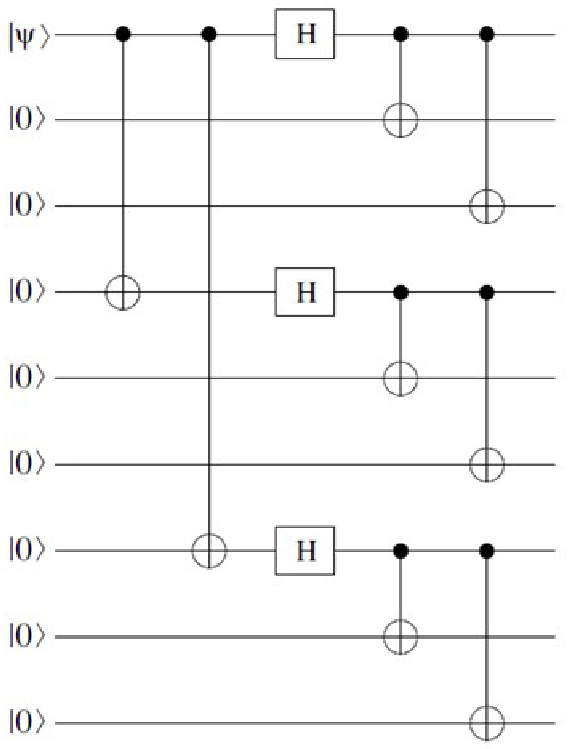
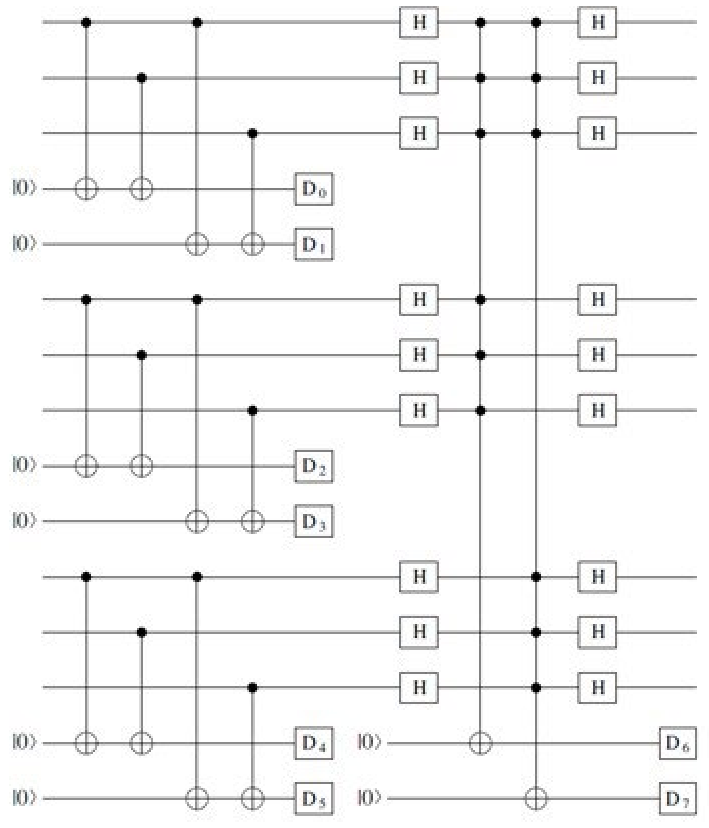

## Arquitectura del Circuito Implementado
Para evaluar la tolerancia a fallos sobre un único cúbit lógico, el circuito se ha estructurado de forma modular con los siguientes registros:

* Registro de Datos (`q_datos` - 9 cúbits): Bloque de 9 cúbits físicos utilizado para almacenar y distribuir la información redundante de un único estado cuántico original $|\psi\rangle$.
* Registro de Ancillas (`q_ancila` - 8 cúbits): Cúbits auxiliares que almacenan la firma de los errores mediante entrelazamiento. Las ancillas `qa[0]` a `qa[5]` calculan la paridad local mediante compuertas CNOT para detectar volteos de bit ($X$), mientras que `qa[6]` y `qa[7]` miden el cambio de fase global ($Z$) entrelazándose con bloques de datos envueltos en compuertas Hadamard.
* Registro de Síndromes (`c_reg` - 8 bits clásicos): Bits que almacenan el resultado de medir las ancillas. Sirven como diagnóstico preciso del error.
* Registro de Salida (`c_salida` - 1 bit clásico): Canal final que mide el mensaje una vez descifrado y restaurado.

*Para ejecutar el cuaderno es necesario instalar las librerías y reiniciar el kernel*

In [1]:
pip install qiskit qiskit_aer numpy matplotlib pylatexenc


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import numpy as np

## Desarrollo del Algoritmo

El circuito de Shor se ha dividido en funciones independientes que reciben el circuito (`qc`), operan sobre sus registros y lo devuelven modificado para la siguiente etapa.

### Inicialización (`inicializar_circuito`)
Esta función se encarga de crear la estructura de hardware (los registros cuánticos de datos y ancillas, y los registros clásicos de medición), para luego cargar el estado cuántico inicial $|\psi\rangle$ en el primer cúbit físico (`q_datos[0]`) mediante `qc.initialize`.

### Cifrado Cuántico (`cifrar_shor`)
Aplica la codificación en cascada del algoritmo para transformar el estado del cúbit original $|\psi\rangle$ en un cúbit lógico redundante distribuido a lo largo de los 9 cúbits del registro `q_datos`.

### Inyección de Ruido (`inyectar_error`)
Este módulo simula de forma controlada el ruido del entorno real sobre el procesador. Lo consigue aplicando compuertas de Pauli sobre el cúbit que recibe como parámetro para simular fallos: `flip` (compuerta $X$), `fase` (compuerta $Z$) o `ambos` (compuerta $Y$).

### Análisis del Síndrome (`analizar_sindrome`)
Su función es realizar el entrelazamiento cuántico necesario para detectar errores sin destruir el estado de superposición del cúbit lógico. En este proceso, las ancillas `qa[0]` a `qa[5]` calculan la paridad para identificar fallos de tipo Bit-Flip ($X$), mientras que `qa[6]` y `qa[7]` se apoyan en un cambio de base mediante compuertas $H$ para transferir los errores de Phase-Flip ($Z$) a las ancillas. Al terminar esta etapa, la información de los fallos reside exclusivamente en el estado cuántico del registro `q_ancila`.

### Medición del Síndrome (`medir_sindrome`)
Este módulo proyecta el estado cuántico de las ancillas transfiriendo su información al registro clásico `c_reg`. Al separar esta lectura del análisis, se genera un punto de control ideal que colapsa las ancillas en patrones binarios de bits (síndromes), permitiendo tanto la toma de decisiones condicionales en el circuito como la auditoría estadística del ruido.

### Corrección Activa (`corregir_errores`)
Esta etapa aplica la lógica de reparación basada en el síndrome medido en las ancillas clásicas. Utiliza bloques condicionales (`with qc.if_test`) para que, según el diagnóstico, el circuito aplique de forma dinámica una compuerta $X$ (para subsanar el error de bit), una compuerta $Z$ (para subsanar el error de fase), o ambas compuertas consecutivas ($X$ y luego $Z$) sobre el cúbit dañado en caso de detectarse un error combinado $Y$.

### Descifrado y Medición Final (`descifrar_y_medir`)
Por último, la función deshace el entrelazamiento del cúbit lógico para recuperar el mensaje original en un solo bit limpio. Esto se logra aplicando exactamente las operaciones inversas al cifrado inicial para concentrar la información de vuelta en `q_datos[0]`, midiendo finalmente ese cúbit en el registro `c_salida` para verificar que el dato sobrevivió al ruido.

In [3]:
def inicializar_circuito(estado_inicial):
    """
    1. Crea los registros e inicializa el mensaje cuántico.
    """
    q_datos = QuantumRegister(9, 'q')
    q_ancila = QuantumRegister(8, 'qa')
    c_reg = ClassicalRegister(8, 'cr')
    c_salida = ClassicalRegister(1, 'out')
    
    qc = QuantumCircuit(q_datos, q_ancila, c_reg, c_salida)
    
    # Inicialización con el vector de estado recibido
    qc.initialize(estado_inicial.data, q_datos[0])
    return qc

def cifrar_shor(qc):
    """
    2. Fase de Cifrado (Codificación del cúbit lógico).
    """
    q_datos = qc.qregs[0]
    
    qc.cx(q_datos[0], q_datos[3])
    qc.cx(q_datos[0], q_datos[6])
    for cubit in (0, 3, 6):
        qc.h(q_datos[cubit])
    
    qc.cx(q_datos[0], q_datos[1])
    qc.cx(q_datos[0], q_datos[2])
    qc.cx(q_datos[3], q_datos[4])
    qc.cx(q_datos[3], q_datos[5])
    qc.cx(q_datos[6], q_datos[7])
    qc.cx(q_datos[6], q_datos[8])
    qc.barrier(label="Fin cúbit lógico")
    return qc

def inyectar_error(qc, cubit_error, tipo_error):
    """
    3. Fase de Ruido/Error (Inyección controlada en un cúbit).
    """
    q_datos = qc.qregs[0]
    
    if (cubit_error != -1):
        if (tipo_error == "flip"):
            qc.x(q_datos[cubit_error])
        if (tipo_error == "fase"):
            qc.z(q_datos[cubit_error])
        if (tipo_error == "ambos"):
            qc.x(q_datos[cubit_error])
            qc.z(q_datos[cubit_error])
            
    return qc

def analizar_sindrome(qc):
    """
    4. Fase de Análisis del Síndrome (Detección cuántica de X y Z).
    Aplica las compuertas para entrelazar las ancillas con los errores.
    """
    q_datos = qc.qregs[0]
    q_ancila = qc.qregs[1]

    # --- ANÁLISIS DEL SÍNDROME X (Bit-Flip) ---
    qc.cx(q_datos[0], q_ancila[0]); qc.cx(q_datos[1], q_ancila[0])
    qc.cx(q_datos[0], q_ancila[1]); qc.cx(q_datos[2], q_ancila[1])
    qc.cx(q_datos[3], q_ancila[2]); qc.cx(q_datos[4], q_ancila[2])
    qc.cx(q_datos[3], q_ancila[3]); qc.cx(q_datos[5], q_ancila[3])
    qc.cx(q_datos[6], q_ancila[4]); qc.cx(q_datos[7], q_ancila[4])
    qc.cx(q_datos[6], q_ancila[5]); qc.cx(q_datos[8], q_ancila[5])
    
    # --- ANÁLISIS DEL SÍNDROME Z (Phase-Flip) ---
    for i in range(9): qc.h(q_datos[i])
    for i in range(6): qc.cx(q_datos[i], q_ancila[6])
        
    for i in range(3):
        qc.cx(q_datos[i], q_ancila[7])
        qc.cx(q_datos[i+6], q_ancila[7])
    
    for i in range(9): qc.h(q_datos[i])
    return qc

def medir_sindrome(qc):
    """
    5. Fase de Medición del Síndrome.
    Proyecta el estado de las ancillas en el registro clásico para la corrección.
    """
    q_ancila = qc.qregs[1]
    c_reg = qc.cregs[0]
    
    # Medir ancillas de Bit-Flip (0 a 5)
    for i in range(6):
        qc.measure(q_ancila[i], c_reg[i])
        
    # Medir ancillas de Phase-Flip (6 y 7)
    qc.measure(q_ancila[6], c_reg[6])
    qc.measure(q_ancila[7], c_reg[7]) 
    qc.barrier(label="Fin sindrome")
    return qc

def corregir_errores(qc, correccion):
    """
    6. Fase de Corrección basada en los resultados condicionales (if_test).
    """
    if not correccion:
        return qc
        
    q_datos = qc.qregs[0]
    c_reg = qc.cregs[0]
    
    # --- Corrección Bit-Flip (X) ---
    with qc.if_test((c_reg[0], 0)):
        with qc.if_test((c_reg[1], 1)): qc.x(q_datos[2])
    with qc.if_test((c_reg[0], 1)):
        with qc.if_test((c_reg[1], 0)): qc.x(q_datos[1])
    with qc.if_test((c_reg[0], 1)):
        with qc.if_test((c_reg[1], 1)): qc.x(q_datos[0])
            
    with qc.if_test((c_reg[2], 0)):
        with qc.if_test((c_reg[3], 1)): qc.x(q_datos[5])
    with qc.if_test((c_reg[2], 1)):
        with qc.if_test((c_reg[3], 0)): qc.x(q_datos[4])
    with qc.if_test((c_reg[2], 1)):
        with qc.if_test((c_reg[3], 1)): qc.x(q_datos[3])

    with qc.if_test((c_reg[4], 0)):
        with qc.if_test((c_reg[5], 1)): qc.x(q_datos[8])
    with qc.if_test((c_reg[4], 1)):
        with qc.if_test((c_reg[5], 0)): qc.x(q_datos[7])
    with qc.if_test((c_reg[4], 1)):
        with qc.if_test((c_reg[5], 1)): qc.x(q_datos[6])

    # --- Corrección Phase-Flip (Z) ---
    # Síndrome 11000000 (c_reg[7]=1, c_reg[6]=1) -> Error en Bloque 1. Corregir Q0
    with qc.if_test((c_reg[7], 1)):
        with qc.if_test((c_reg[6], 1)): qc.z(q_datos[0])
        
    # Síndrome 01000000 (c_reg[7]=0, c_reg[6]=1) -> Error en Bloque 2. Corregir Q3 
    with qc.if_test((c_reg[7], 0)):
        with qc.if_test((c_reg[6], 1)): qc.z(q_datos[3])
        
    # Síndrome 10000000 (c_reg[7]=1, c_reg[6]=0) -> Error en Bloque 3. Corregir Q6
    with qc.if_test((c_reg[7], 1)):
        with qc.if_test((c_reg[6], 0)): qc.z(q_datos[6])
        
    qc.barrier(label="Fin Correccion")
    return qc

def descifrar_y_medir(qc):
    """
    7 y 8. Fase de Descifrado (Descodificación) y Medición Final.
    """
    q_datos = qc.qregs[0]
    c_salida = qc.cregs[1]
    
    # Deshacer el cúbit lógico
    qc.cx(q_datos[6], q_datos[8]); qc.cx(q_datos[6], q_datos[7])
    qc.cx(q_datos[3], q_datos[5]); qc.cx(q_datos[3], q_datos[4])
    qc.cx(q_datos[0], q_datos[2]); qc.cx(q_datos[0], q_datos[1])
    for cubit in (0, 3, 6):
        qc.h(q_datos[cubit])
    qc.cx(q_datos[0], q_datos[6])
    qc.cx(q_datos[0], q_datos[3])
    
    # Medición final del mensaje
    qc.measure(q_datos[0], c_salida[0])
    return qc

### Orquestador del Algoritmo (`shor_completo`)
Esta función actúa como el organizador central del pipeline, coordinando la ejecución secuencial de todos los módulos anteriores en un único circuito unificado. A través de sus parámetros, inicializa el sistema con el estado deseado, define las condiciones del error ambiental y determina si se debe activar la lógica de reparación. Al enlazar de forma ordenada las etapas de cifrado, inyección de ruido, análisis y medición del síndrome, corrección condicional y descifrado, devuelve el circuito totalmente estructurado y listo para ser ejecutado mediante muestreo estadístico en el simulador.

### Orquestador de Auditoría (`shor_pruebas_sindrome`)
Esta función ofrece un pipeline alternativo diseñado exclusivamente para la verificación experimental del síndrome en un simulador de vectores de estado (`Statevector`). A diferencia del flujo completo, este orquestador interrumpe la ejecución justo después de la etapa cuántica de `analizar_sindrome`. Al omitir la medición física de las ancillas y la subsecuente corrección, se evita el colapso de la función de onda, permitiendo auditar matemáticamente el estado puro de superposición del registro `q_ancila` tras interactuar con el ruido.

In [4]:
def shor_completo(estado_inicial, cubit_error, tipo_error, correccion):
    """
    Orquesta el pipeline completo del algoritmo de corrección de Shor.
    """
    # 1. Inicialización
    qc = inicializar_circuito(estado_inicial)
    
    # 2. Cifrado
    qc = cifrar_shor(qc)
    
    # 3. Inyección del error ambiental
    qc = inyectar_error(qc, cubit_error, tipo_error)
    
    # 4. Análisis del síndrome (Entrelazamiento cuántico con ancillas)
    qc = analizar_sindrome(qc)
    
    # 5. Medición del síndrome (Paso de información a registros clásicos)
    qc = medir_sindrome(qc)
    
    # 6. Corrección condicional (Usa los resultados medidos en el paso anterior)
    qc = corregir_errores(qc, correccion)
    
    # 7 y 8. Descifrado y lectura final del mensaje
    qc = descifrar_y_medir(qc)
    
    return qc

def shor_pruebas_sindrome(estado_inicial, cubit_error, tipo_error):
    """
    Orquesta el pipeline parcial del algoritmo de Shor para evaluar
    exclusivamente el estado cuántico del síndrome (Statevector).
    
    NO mide las ancillas para evitar el colapso del estado, permitiendo
    auditar la función de onda pura del sistema completo.
    """
    # 1. Inicialización
    qc = inicializar_circuito(estado_inicial)
    
    # 2. Cifrado
    qc = cifrar_shor(qc)
    
    # 3. Inyección del error ambiental
    qc = inyectar_error(qc, cubit_error, tipo_error)
    
    # 4. Análisis del síndrome (Entrelazamiento cuántico con las ancillas)
    qc = analizar_sindrome(qc)
    
    return qc

## Visualización del Circuito Completo

Con el objetivo de verificar la correcta integración de todos los módulos del pipeline y comprobar la disposición secuencial de las compuertas y registros, se genera una representación gráfica del circuito completo. 

Para esta inspección visual, se construye una instancia del algoritmo en condiciones ideales (sin inyección de ruido) y con la lógica de corrección activa habilitada. Esto permite auditar la arquitectura de hardware diseñada antes de proceder con las simulaciones numéricas y masivas de los escenarios de error.

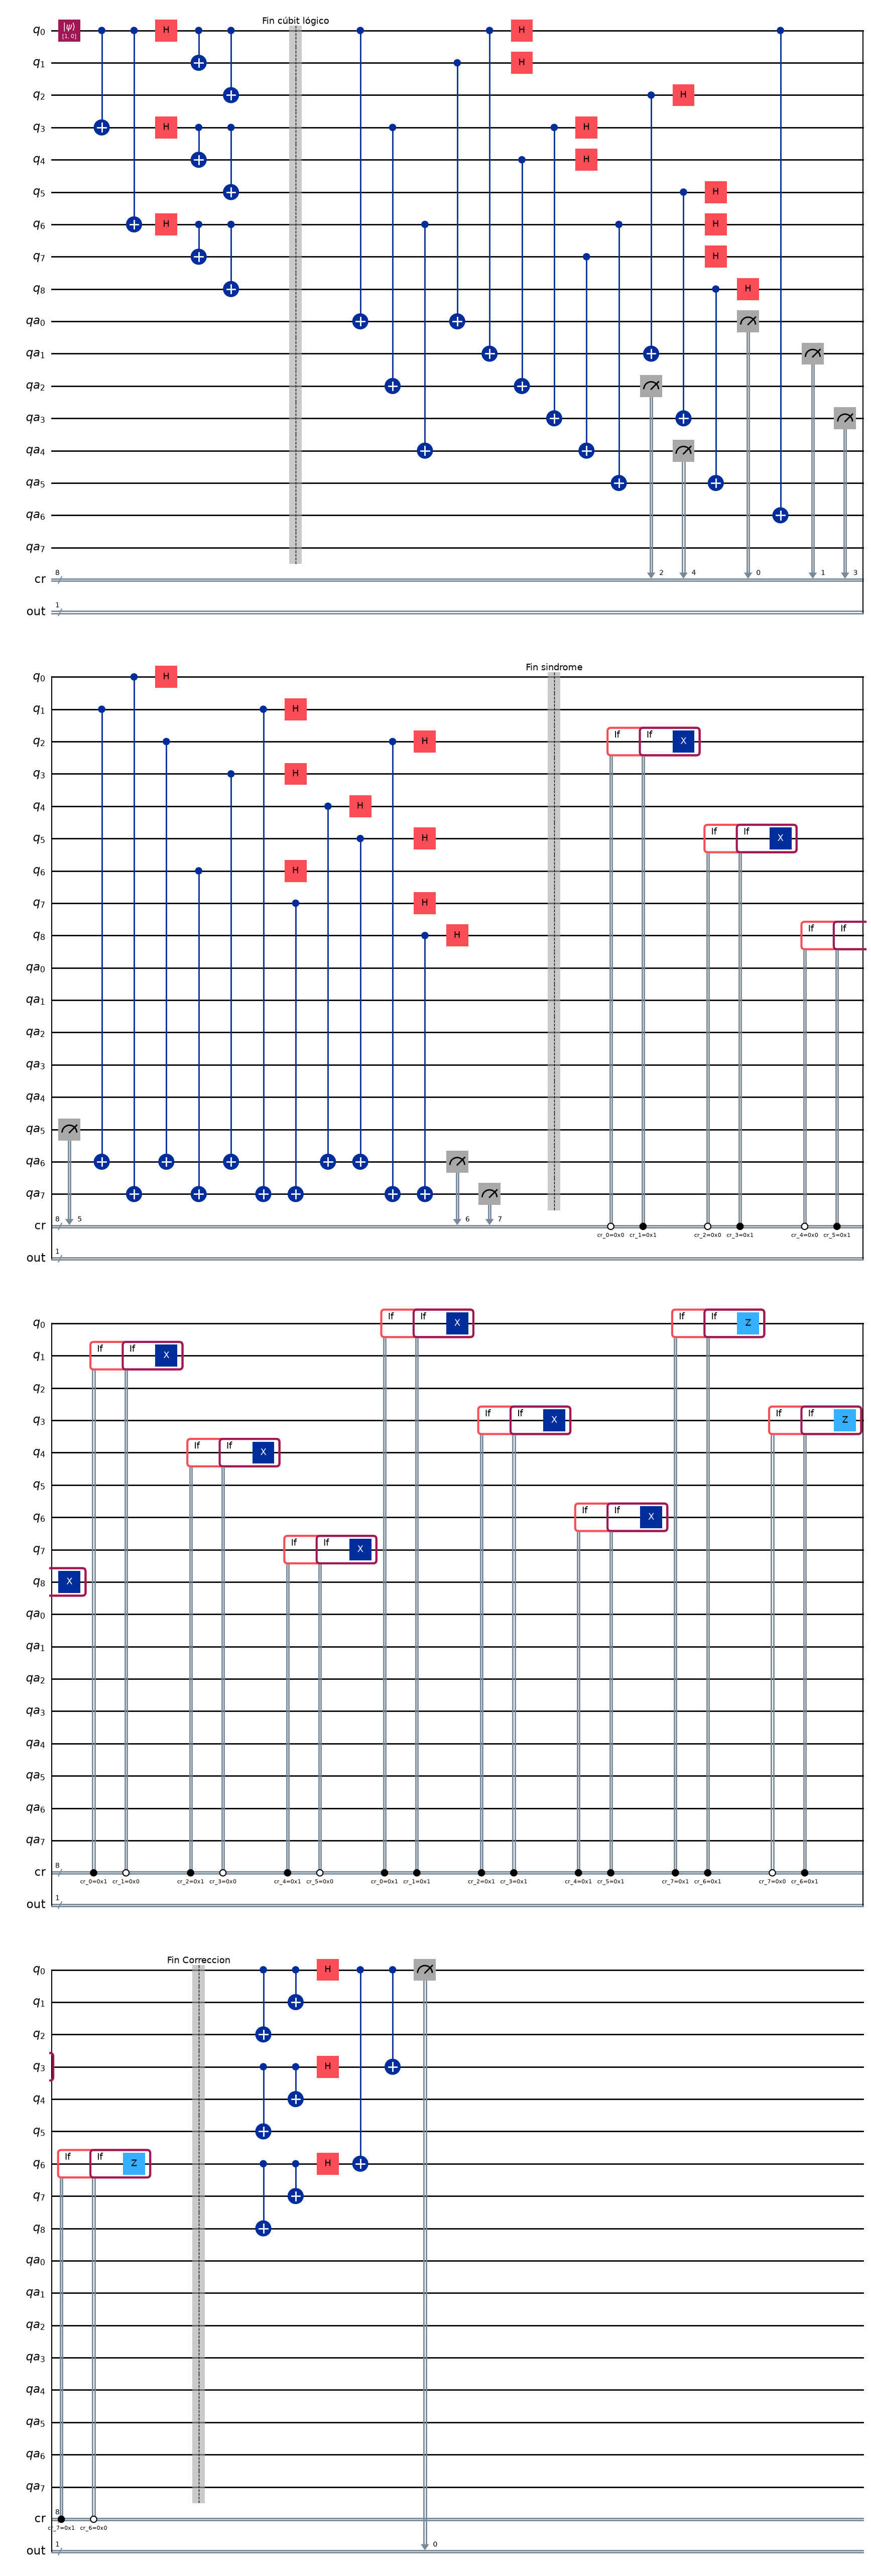

In [5]:
# Se define un estado de prueba local
estado_visualizacion = Statevector([1, 0])

# Se genera el circuito completo usando el orquestador
qc_visualizar = shor_completo(estado_visualizacion, cubit_error=-1, tipo_error="none", correccion=True)

# Se dibuja el circuito con el empaquetador de Matplotlib
qc_visualizar.draw('mpl')

### Verificación del Circuito y Análisis Sistemático del Síndrome

Este bloque de código valida la estructura interna del circuito de Shor. Consiste en un bucle automatizado que somete al sistema a 13 escenarios de error distribuidos en tres categorías fundamentales: errores de volteo de bit ($X$) para validar las reglas de paridad en los tres subbloques, errores de volteo de fase ($Z$) para verificar la detección mediante el cambio de base con compuertas Hadamard, y un error combinado ($Y$) como caso de distorsión simultánea.

Para cada escenario, el script construye el circuito de forma modular utilizando el estado inicial $|1\rangle$, inyecta la perturbación controlada en el cúbit físico seleccionado y evalúa el circuito en la etapa de detección. A través del análisis del vector de estado del sistema combinado y recupera el valor del síndrome proyectado en los registros del síndrome clásico. Finalmente, el script mapea cada configuración de bits con su respectiva operación cuántica de recuperación ($I, X, Z, Y$), generando la tabla de diagnóstico.

In [6]:
# Se define una lista de escenarios de prueba para auditar el síndrome
# Formato: (cúbit_afectado, tipo_de_error, descripción_para_el_reporte)
escenarios = [
    # --- GRUPO 1: CONTROL Y ERRORES DE BIT (X) ---
    (-1, "none", "Caso Ideal (Sin Errores)"),
    (0, "flip", "Bit-Flip (X) en Q0"),
    (1, "flip", "Bit-Flip (X) en Q1"),
    (2, "flip", "Bit-Flip (X) en Q2"),
    
    (3, "flip", "Bit-Flip (X) en Q3"),
    (4, "flip", "Bit-Flip (X) en Q4"),
    (5, "flip", "Bit-Flip (X) en Q5"),
    
    (6, "flip", "Bit-Flip (X) en Q6"),
    (8, "flip", "Bit-Flip (X) en Q8"),
    
    # --- GRUPO 2: ERRORES DE FASE (Z) ---
    (0, "fase", "Phase-Flip (Z) en Q0"),
    (3, "fase", "Phase-Flip (Z) en Q3"),
    (6, "fase", "Phase-Flip (Z) en Q6"),
    
    # --- GRUPO 3: CASO EXTREMO COMBINADO ---
    (0, "ambos", "Error Completo (Y) en Q0")
]

# Cabecera con terminología rigurosa para el reporte
print(f"{'Escenario de Error':<28} | {'Tipo':<6} | {'Cúbit':<6} | {'Síndrome Clásico':<16} | {'Acción de Recuperación'}")
print("-" * 85)

# Estado inicial fijado en |1> para las pruebas
estado_entrada = Statevector([0, 1])

for q_err, t_err, desc in escenarios:
    # 1. Generación del circuito parcial mediante el orquestador de pruebas
    qc = shor_pruebas_sindrome(estado_entrada, q_err, t_err)
    
    # 2. Extracción del Vector de Estado
    vector_estado = Statevector.from_instruction(qc)
    diccionario = vector_estado.to_dict()
    
    # 3. Búsqueda de la base con probabilidad no nula para extraer el síndrome clásico
    for estado_binario, amplitud in diccionario.items():
        if abs(amplitud) > 0.01:
            # Separación del registro clásico del síndrome
            # Se extrae los bits clásicos correspondientes a las mediciones
            sindrome_clasico = estado_binario[-17:-9]
            
            # 4. Mapeo de la acción (Recuperación)
            if t_err == "none":
                tipo_latex = "-"
                cubit_latex = "-"
                recuperacion = "No actuar (Identidad I)"
            elif t_err == "flip":
                tipo_latex = "$X$"
                cubit_latex = f"$Q_{q_err}$"
                recuperacion = f"Aplicar puerta X en Q{q_err}"
            elif t_err == "fase":
                tipo_latex = "$Z$"
                cubit_latex = f"$Q_{q_err}$"
                recuperacion = f"Aplicar puerta Z en Q{q_err}"
            elif t_err == "ambos":
                tipo_latex = "$Y$"
                cubit_latex = f"$Q_{q_err}$"
                recuperacion = f"Aplicar puertas X y Z en Q{q_err}"
            
            # Imprimir salida limpia en consola
            print(f"{desc:<28} | {tipo_latex:<4} | {cubit_latex:<5} | {sindrome_clasico:<16} | {recuperacion}")        
            break  # Transición inmediata al siguiente escenario de error

Escenario de Error           | Tipo   | Cúbit  | Síndrome Clásico | Acción de Recuperación
-------------------------------------------------------------------------------------
Caso Ideal (Sin Errores)     | -    | -     | 00000000         | No actuar (Identidad I)
Bit-Flip (X) en Q0           | $X$  | $Q_0$ | 00000011         | Aplicar puerta X en Q0
Bit-Flip (X) en Q1           | $X$  | $Q_1$ | 00000001         | Aplicar puerta X en Q1
Bit-Flip (X) en Q2           | $X$  | $Q_2$ | 00000010         | Aplicar puerta X en Q2
Bit-Flip (X) en Q3           | $X$  | $Q_3$ | 00001100         | Aplicar puerta X en Q3
Bit-Flip (X) en Q4           | $X$  | $Q_4$ | 00000100         | Aplicar puerta X en Q4
Bit-Flip (X) en Q5           | $X$  | $Q_5$ | 00001000         | Aplicar puerta X en Q5
Bit-Flip (X) en Q6           | $X$  | $Q_6$ | 00110000         | Aplicar puerta X en Q6
Bit-Flip (X) en Q8           | $X$  | $Q_8$ | 00100000         | Aplicar puerta X en Q8
Phase-Flip (Z) en Q0         |

### Simulación de Múltiples Lanzamientos (*Shots*) y Validación Externa
Este bloque de código implementa la batería de pruebas definitivas sobre el circuito completo a través de un enfoque estadístico y de ingeniería. El script utiliza el simulador local de Qiskit (`AerSimulator`) para someter la arquitectura a una serie de escenarios ruidosos predeterminados bajo condiciones ideales. Para cada caso (como la ausencia de fallos, volteos de bit o desfases en cúbits clave), la función orquestadora genera la estructura del circuito activando la lógica de reparación basada en condicionales clásicos.

El proceso ejecuta cada configuración un total de 500 veces (*shots*). Al procesar los resultados acumulados mediante el diccionario de recuentos (`get_counts`), el bucle extrae y formatea de manera automática la salida binaria para aislar el bit clásico de lectura final (`out`) del "código de barras" del diagnóstico clásico (`cr7...cr0`). Esto permite verificar visualmente la solidez del circuito en una tabla de reporte, demostrando de forma empírica si el algoritmo de Shor es capaz de restaurar el mensaje original con un 100% de efectividad ante fallos cuánticos.

In [7]:
# ==========================================
# 1. DEFINICIÓN DEL ESTADO INICIAL (EL MENSAJE)
# ==========================================
# Se realiza la comprobación con el estado |1> (vector [0, 1]).
# Si el circuito opera correctamente y subsana el ruido, el bit 'out' final DEBE SER SIEMPRE 1.
estado_test = Statevector([0, 1]) 

# ==========================================
# 2. SELECCIÓN DE ESCENARIOS DE PRUEBA
# ==========================================
# El circuito se somete a los siguientes vectores de fallo:
casos_prueba = [
    (-1, "none"), # Caso de control
    
    # --- VOLTEO DE BIT (X) ---
    (0, "flip"), (1, "flip"), (2, "flip"), # Bloque 1
    (3, "flip"), (4, "flip"), (5, "flip"), # Bloque 2
    (6, "flip"), (7, "flip"), (8, "flip"), # Bloque 3
    
    # --- VOLTEO DE FASE (Z) ---
    (0, "fase"), (1, "fase"), (2, "fase"), # Bloque 1
    (3, "fase"), (4, "fase"), (5, "fase"), # Bloque 2
    (6, "fase"), (7, "fase"), (8, "fase"), # Bloque 3
    
    # --- CASO COMBINADO (Y) ---
    (0, "ambos")
]

# Inicialización del backend de simulación
simulador = AerSimulator()

print(f"{'Caso de Error':<22} | {'Resultados (out cr7..cr0)':<30} | ¿Funcionó la Corrección?")
print("-" * 85)

# ==========================================
# 3. EJECUCIÓN COLECTIVA DE LA BATERÍA
# ==========================================
for q_err, t_err in casos_prueba:
    # Construcción del circuito completo mediante el nuevo pipeline orquestado
    # La corrección activa se encuentra habilitada (correccion=True)
    qc_prueba = shor_completo(estado_test, q_err, t_err, correccion=True)
    
    # Simulación del comportamiento estadístico mediante 500 lanzamientos (shots)
    recuento = simulador.run(qc_prueba, shots=500).result().get_counts()
    
    # Formateo y procesamiento de las lecturas obtenidas para la generación de la tabla
    for clave, valor in recuento.items():
        # Extracción y separación del bit clásico de salida y los bits de las ancillas
        bit_salida = clave.split()[0]
        sindrome_binario = clave.split()[1]
        
        # Validación automatizada del estado lógico final frente al estado inicial inyectado
        exito = "SÍ - Mensaje Recuperado" if bit_salida == "1" else "NO - Mensaje Corrupto"
        
        nombre_error = f"Q{q_err} con {t_err}" if q_err != -1 else "Sin Errores"
        print(f"{nombre_error:<22} | {bit_salida} [{sindrome_binario}] ({valor} veces) | {exito}")

Caso de Error          | Resultados (out cr7..cr0)      | ¿Funcionó la Corrección?
-------------------------------------------------------------------------------------
Sin Errores            | 1 [00000000] (500 veces) | SÍ - Mensaje Recuperado
Q0 con flip            | 1 [00000011] (500 veces) | SÍ - Mensaje Recuperado
Q1 con flip            | 1 [00000001] (500 veces) | SÍ - Mensaje Recuperado
Q2 con flip            | 1 [00000010] (500 veces) | SÍ - Mensaje Recuperado
Q3 con flip            | 1 [00001100] (500 veces) | SÍ - Mensaje Recuperado
Q4 con flip            | 1 [00000100] (500 veces) | SÍ - Mensaje Recuperado
Q5 con flip            | 1 [00001000] (500 veces) | SÍ - Mensaje Recuperado
Q6 con flip            | 1 [00110000] (500 veces) | SÍ - Mensaje Recuperado
Q7 con flip            | 1 [00010000] (500 veces) | SÍ - Mensaje Recuperado
Q8 con flip            | 1 [00100000] (500 veces) | SÍ - Mensaje Recuperado
Q0 con fase            | 1 [11000000] (500 veces) | SÍ - Mensaje Recupe